Dataset Loaded: (20, 5)

=== DATA INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   vendor_name     20 non-null     object 
 1   total_quantity  20 non-null     float64
 2   avg_cost        20 non-null     float64
 3   avg_defect      20 non-null     float64
 4   total_cost      20 non-null     float64
dtypes: float64(4), object(1)
memory usage: 928.0+ bytes
None

=== STATISTICS ===
       total_quantity    avg_cost  avg_defect    total_cost
count       20.000000   20.000000   20.000000  2.000000e+01
mean    237130.708970  417.915718    6.223434  3.493292e+07
std      11996.088396   24.139323    0.121925  1.928158e+06
min     217322.843400  387.211154    6.000773  3.149693e+07
25%     230529.578025  400.380265    6.145918  3.370936e+07
50%     235263.954650  411.631062    6.215895  3.514630e+07
75%     242697.435125  428.057171    6

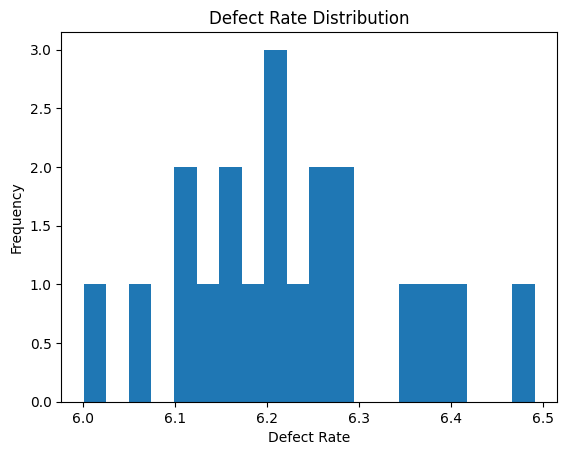

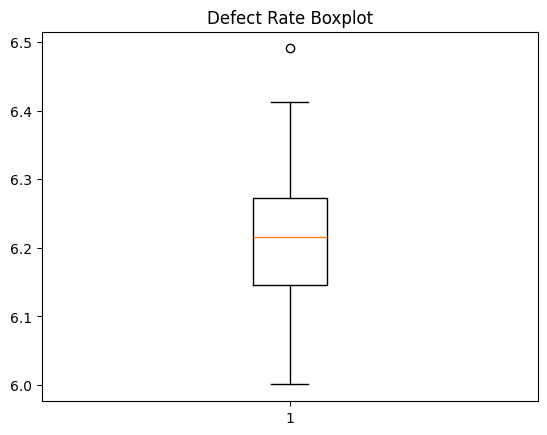


Outliers Detected: 1

Top 10 Worst Vendors:
                          vendor_name  avg_defect
11        phondaghat_pharmacy_&_honey    6.490508
1             hubli_fresh_produce_co.    6.411993
9   sahaja_samrudha_organic_producers    6.392050
8                       tapcms_hassan    6.355102
5                  malnad_nutri_foods    6.276495
0         sri_nanjundeshwara_apiaries    6.270574
13       chikkamagaluru_spice_traders    6.252308
14           dharwad_seed_&_spice_fpo    6.248895
18                 tumkur_agro_supply    6.235030
19    mandya_organic_farmers_alliance    6.217916

Top 10 Best Vendors:
                           vendor_name  avg_defect
3     belagavi_veg_growers_association    6.000773
10       shimoga_agri_tech_cooperative    6.056507
2           bagalkot_onion_growers_fpc    6.108810
7                     campco_mangaluru    6.112117
4            mysore_spices_&_herbs_hub    6.128750
16  dakshina_kannada_exporters_network    6.151641
15   kodagu_district_spice

In [1]:

# Day 12 - Defect Rate Analysis
# ==========================================================

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent

INPUT_FILE = PROJECT_ROOT / "03_processed_data/vendor_performance.csv"

OUTPUT_DIR = PROJECT_ROOT / "03_processed_data"
VIS_DIR = PROJECT_ROOT / "04_visualizations"

OUTPUT_DIR.mkdir(exist_ok=True)
VIS_DIR.mkdir(exist_ok=True)

# ----------------------------------------------------------
# LOAD DATA
# ----------------------------------------------------------

df = pd.read_csv(INPUT_FILE)

print("Dataset Loaded:", df.shape)

# ----------------------------------------------------------
# 1. DATA PROFILING
# ----------------------------------------------------------

print("\n=== DATA INFO ===")
print(df.info())

print("\n=== STATISTICS ===")
print(df.describe())

print("\n=== MISSING VALUES ===")
print(df.isnull().sum())

# ----------------------------------------------------------
# 2. DEFECT DISTRIBUTION
# ----------------------------------------------------------

plt.figure()

plt.hist(df["avg_defect"], bins=20)

plt.xlabel("Defect Rate")
plt.ylabel("Frequency")
plt.title("Defect Rate Distribution")

plt.savefig(VIS_DIR / "defect_distribution.png")
plt.show()
plt.close()

# ----------------------------------------------------------
# 3. BOXPLOT (OUTLIERS VISUAL)
# ----------------------------------------------------------

plt.figure()

plt.boxplot(df["avg_defect"])

plt.title("Defect Rate Boxplot")

plt.savefig(VIS_DIR / "defect_boxplot.png")
plt.show()
plt.close()

# ----------------------------------------------------------
# 4. OUTLIER DETECTION (IQR METHOD)
# ----------------------------------------------------------

Q1 = df["avg_defect"].quantile(0.25)
Q3 = df["avg_defect"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df["avg_defect"] < lower_bound) |
    (df["avg_defect"] > upper_bound)
]

print("\nOutliers Detected:", len(outliers))

# SAVE OUTLIERS
outliers.to_csv(
    OUTPUT_DIR / "defect_outliers.csv",
    index=False
)

# ----------------------------------------------------------
# 5. VENDOR RANKING (QUALITY)
# ----------------------------------------------------------

# Worst Vendors (High Defect)
worst_vendors = df.sort_values(
    by="avg_defect",
    ascending=False
).head(10)

# Best Vendors (Low Defect)
best_vendors = df.sort_values(
    by="avg_defect"
).head(10)

print("\nTop 10 Worst Vendors:")
print(worst_vendors[["vendor_name", "avg_defect"]])

print("\nTop 10 Best Vendors:")
print(best_vendors[["vendor_name", "avg_defect"]])

# SAVE RESULTS
worst_vendors.to_csv(
    OUTPUT_DIR / "top_defect_vendors.csv",
    index=False
)

best_vendors.to_csv(
    OUTPUT_DIR / "best_quality_vendors.csv",
    index=False
)

# ----------------------------------------------------------
# 6. ABOVE AVERAGE DEFECT ANALYSIS
# ----------------------------------------------------------

avg_defect = df["avg_defect"].mean()

above_avg = df[df["avg_defect"] > avg_defect]

percentage = (len(above_avg) / len(df)) * 100

print("\nAverage Defect Rate:", avg_defect)
print("Vendors Above Average Defect:", len(above_avg))
print("Percentage Above Average: {:.2f}%".format(percentage))

# SAVE
above_avg.to_csv(
    OUTPUT_DIR / "above_avg_defect_vendors.csv",
    index=False
)

# ----------------------------------------------------------
# 7. FINAL STATUS
# ----------------------------------------------------------

print("\nDay 12 Defect Analysis Completed Successfully")